# Main Results — IQL with Disentangled Representations

Evaluates the primary experiment: IQL policy trained on top of various encoder methods  
under nonlinear observation noise across multiple environments.

**Methods covered**
- Disentangled: `barlow`, `dcor`, `hsic`, `cov`, `infonce`, `l1`  
  (comment out methods not yet run)
- Baselines: `plain`, `raw_noisy`, `true_only`

**Cell layout**
- Cell 1 — Imports & project root  
- Cell 2 — Tunable config  
- Cell 3 — Plot style  
- Cell 4 — Method labels, order, palette  
- Step 1 — Load metrics  
- Step 2 — Plot helpers  
- Step 3 — Save tables  
- Step 4 — Generate & save figures

In [56]:
from pathlib import Path
import json
import re
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "results").exists():
            return candidate
    raise RuntimeError("Cannot locate project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import (
    RAW_METRICS_DIR,
    FIGURES_MAIN_DIR,
    TABLES_MAIN_DIR,
)

print(f"PROJECT_ROOT     = {PROJECT_ROOT}")
print(f"RAW_METRICS_DIR  = {RAW_METRICS_DIR}")
print(f"FIGURES_MAIN_DIR = {FIGURES_MAIN_DIR}")
print(f"TABLES_MAIN_DIR  = {TABLES_MAIN_DIR}")

PROJECT_ROOT     = /home/wyuhan/projects/robust-offline-rl-disentanglement
RAW_METRICS_DIR  = /home/wyuhan/projects/robust-offline-rl-disentanglement/results/raw_metrics
FIGURES_MAIN_DIR = /home/wyuhan/projects/robust-offline-rl-disentanglement/results/main/figures
TABLES_MAIN_DIR  = /home/wyuhan/projects/robust-offline-rl-disentanglement/results/main/tables


In [57]:
# ============================================================
# Tunable config — modify this cell only
# ============================================================

TARGET_METHODS = [
    "disentangled_barlow",
    "disentangled_dcor",
    "disentangled_hsic",
    "disentangled_cov",
    "disentangled_infonce",
    "disentangled_l1",
    "plain",
    "raw_noisy",
    "true_only",
]

TARGET_ENVS = [
    # "halfcheetah-medium-v2",
    "hopper-medium-v2",
    # "ant-medium-v2",
]

TARGET_SEEDS  = [1, 2, 3]
# TARGET_SEEDS  = [1, 2, 3, 5]
TARGET_TYPES  = ["nonlinear"]

# Noise dims: set to match the selected env(s)
#   halfcheetah-medium-v2 : [4, 8, 13, 17]
#   hopper-medium-v2      : [3, 6, 8, 11]
#   ant-medium-v2         : [28, 56, 83, 111]
# TARGET_DIMS   = [4, 8, 13, 17]
# TARGET_DIMS   = [17, 34]
# TARGET_DIMS   = [5, 10, 20, 40, 80]
TARGET_DIMS   = [3, 6, 8, 11]
# TARGET_DIMS   = [28, 56, 83, 111]
TARGET_SCALES = [0.5, 1.0, 1.5, 2.0]
# TARGET_SCALES = [0.5, 1.0, 2.0, 4.0, 8.0]

SAVE_FIGURES = True
SAVE_TABLES  = True
SHOW_FIGURES = True

In [58]:
sns.set_theme(style="whitegrid", font_scale=1.1)

In [59]:
# Display name for each method key
method_labels = {
    "true_only":             "No Noise",
    "plain":                 "Plain",
    "raw_noisy":             "Raw Noisy",
    "disentangled_barlow":   "Barlow",
    "disentangled_dcor":     "dCor",
    "disentangled_hsic":     "HSIC",
    "disentangled_cov":      "Covariance",
    "disentangled_infonce":  "InfoNCE",
    "disentangled_l1":       "L1",
}

# Determines bar/line order in all plots
global_order = [
    "No Noise",
    "Barlow", "dCor", "HSIC",
    "Covariance", "InfoNCE", "L1",
    "Plain",
    "Raw Noisy",
]

palette = {
    "No Noise":    "#2c3e50",
    "Barlow":      "#e74c3c",
    "dCor":        "#8e44ad",
    "HSIC":        "#d35400",
    "Covariance":  "#27ae60",
    "InfoNCE":     "#16a085",
    "L1":          "#2980b9",
    "Plain":       "#3498db",
    "Raw Noisy":   "#95a5a6",
}

## Step 1 — Load metrics

In [60]:
def scale_to_tag(value: float) -> str:
    return str(value).replace(".", "p")


def _infer_method(path_str: str, target_methods) -> str:
    norm = path_str.replace("\\", "/")
    for m in target_methods:
        if f"/{m}/" in norm:
            return m
    return ""


def _infer_env(path: Path, target_envs) -> str:
    parts = set(path.parts)
    for env in target_envs:
        if env in parts:
            return env
    return ""


def load_metrics(
    raw_metrics_dir: Path,
    target_methods,
    target_dims,
    target_scales,
    target_types,
    target_seeds,
    target_envs,
):
    """
    Returns
    -------
    df_noisy  : records for noise-sweep methods
    df_oracle : records for true_only (no noise)
    """
    noisy, oracle = [], []
    seen = set()

    for fp in raw_metrics_dir.rglob("*.json"):
        key = str(fp.resolve())
        if key in seen:
            continue
        seen.add(key)

        try:
            data = json.loads(fp.read_text(encoding="utf-8"))
        except Exception:
            continue

        score = data.get("normalized_score")
        if score is None:
            continue

        norm = str(fp.parent).replace("\\", "/")
        cfg  = data.get("data_config", {})

        method = (
            data.get("method")
            or data.get("group")
            or _infer_method(norm, target_methods)
        )
        if method not in target_methods:
            continue

        env = (
            data.get("env_name")
            or data.get("env")
            or cfg.get("env_name")
            or _infer_env(fp, target_envs)
        )
        if env not in target_envs:
            continue

        seed = data.get("seed", cfg.get("seed"))
        if seed is None:
            m = re.search(r"seed_?(\d+)", norm, re.IGNORECASE)
            seed = int(m.group(1)) if m else None
        else:
            seed = int(seed)

        if method == "true_only":
            if seed in target_seeds:
                oracle.append({"Method": "true_only", "Env": env,
                               "Seed": seed, "Score": float(score)})
            continue

        nd    = data.get("noise_dim",   cfg.get("noise_dim"))
        ns    = data.get("noise_scale", cfg.get("noise_scale"))
        ntype = data.get("noise_type",  cfg.get("noise_type"))

        if None in (nd, ns, ntype):
            continue
        if ntype not in target_types:
            continue
        if int(nd) not in target_dims:
            continue
        if float(ns) not in target_scales:
            continue
        if seed is None or int(seed) not in target_seeds:
            continue

        noisy.append({
            "Method": method, "Env": env,
            "Dim": int(nd), "Scale": float(ns),
            "Type": ntype, "Seed": int(seed),
            "Score": float(score),
        })

    df_noisy  = pd.DataFrame(noisy)
    df_oracle = pd.DataFrame(oracle)

    if not df_oracle.empty:
        df_oracle = (
            df_oracle
            .drop_duplicates(subset=["Env", "Seed"], keep="first")
            .reset_index(drop=True)
        )

    return df_noisy, df_oracle

In [61]:
df_noisy, df_oracle = load_metrics(
    raw_metrics_dir=RAW_METRICS_DIR,
    target_methods=TARGET_METHODS,
    target_dims=TARGET_DIMS,
    target_scales=TARGET_SCALES,
    target_types=TARGET_TYPES,
    target_seeds=TARGET_SEEDS,
    target_envs=TARGET_ENVS,
)

noise_type_str = TARGET_TYPES[0]
seed_tag       = "_".join(str(s) for s in sorted(TARGET_SEEDS))

print(f"Noise-sweep records : {len(df_noisy)}")
print(f"true_only records   : {len(df_oracle)}")

if not df_oracle.empty:
    print(f"Oracle mean score   : {df_oracle['Score'].mean():.3f}")

if not df_noisy.empty:
    print("\nMethods found:", sorted(df_noisy['Method'].unique()))
    print("Envs found:   ", sorted(df_noisy['Env'].unique()))

df_noisy.head()

Noise-sweep records : 240
true_only records   : 3
Oracle mean score   : 41.747

Methods found: ['disentangled_barlow', 'disentangled_dcor', 'disentangled_hsic', 'plain', 'raw_noisy']
Envs found:    ['hopper-medium-v2']


,Method,Env,Dim,Scale,Type,Seed,Score
0,disentangled_dcor,hopper-medium-v2,11,0.5,nonlinear,1,49.609163
1,disentangled_dcor,hopper-medium-v2,11,0.5,nonlinear,3,31.928333
2,disentangled_dcor,hopper-medium-v2,11,0.5,nonlinear,2,46.428120
3,disentangled_dcor,hopper-medium-v2,8,1.5,nonlinear,1,50.707784
4,disentangled_dcor,hopper-medium-v2,8,1.5,nonlinear,3,56.729080


## Step 2 — Plot helpers

In [62]:
def _prepare_plot_df(sub_df, x_col, method_labels, oracle_mean=None):
    """Map method keys to display names; optionally inject oracle reference rows."""
    plot_df = sub_df.copy()
    if oracle_mean is not None:
        oracle_rows = [
            {"Method": "true_only", x_col: x, "Score": oracle_mean}
            for x in plot_df[x_col].unique()
        ]
        plot_df = pd.concat([plot_df, pd.DataFrame(oracle_rows)], ignore_index=True)
    plot_df["Label"] = plot_df["Method"].map(method_labels)
    return plot_df


def _order_labels(plot_df, global_order):
    present = set(plot_df["Label"].dropna())
    return [m for m in global_order if m in present]


def plot_bar(
    sub_df, x_col, x_label, title,
    method_labels, global_order, palette,
    oracle_mean=None, save_path=None, show=True,
):
    if sub_df.empty:
        return
    plot_df = _prepare_plot_df(sub_df, x_col, method_labels, oracle_mean)
    order   = _order_labels(plot_df, global_order)
    plot_df["Label"] = pd.Categorical(plot_df["Label"], categories=order, ordered=True)

    n_x, n_m = len(plot_df[x_col].unique()), len(order)
    plt.figure(figsize=(max(8, n_x * n_m * 0.5), 6))
    ax = sns.barplot(
        data=plot_df, x=x_col, y="Score", hue="Label",
        palette=palette, edgecolor="black", linewidth=1.2, capsize=0.05,
    )
    for patch in ax.patches:
        h = patch.get_height()
        if pd.notna(h) and h > 0:
            ax.annotate(f"{h:.1f}",
                        (patch.get_x() + patch.get_width() / 2, h),
                        ha="center", va="bottom",
                        xytext=(0, 4), textcoords="offset points",
                        fontsize=9, fontweight="bold", rotation=90)

    plt.title(title, fontsize=15, fontweight="bold", pad=12)
    plt.xlabel(x_label, fontsize=13)
    plt.ylabel("Normalized D4RL Score", fontsize=13)
    scores = plot_df["Score"][plot_df["Score"] > 0]
    plt.ylim(max(0, scores.min() - 10), plot_df["Score"].max() + 15)
    plt.legend(title="Method", fontsize=10, title_fontsize=11,
               bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show() if show else plt.close()


def plot_line(
    sub_df, x_col, x_label, title,
    method_labels, global_order, palette,
    oracle_mean=None, save_path=None, show=True,
):
    if sub_df.empty:
        return
    plot_df = _prepare_plot_df(sub_df, x_col, method_labels, oracle_mean=None)
    order   = _order_labels(plot_df, global_order)

    stats = (
        plot_df.groupby(["Label", x_col])["Score"]
        .agg(["mean", "std"]).reset_index()
    )

    plt.figure(figsize=(8, 5))
    ax = plt.gca()
    for label in order:
        cur = stats[stats["Label"] == label].sort_values(x_col)
        if cur.empty:
            continue
        ax.errorbar(
            cur[x_col], cur["mean"], yerr=cur["std"].fillna(0),
            marker="o", capsize=4, linewidth=2, markersize=6,
            label=label, color=palette.get(label, "#aaaaaa"),
        )

    if oracle_mean is not None:
        ax.axhline(oracle_mean, linestyle="--", linewidth=1.8,
                   color=palette.get("No Noise", "#2c3e50"), label="No Noise")

    plt.title(title, fontsize=15, fontweight="bold", pad=12)
    plt.xlabel(x_label, fontsize=13)
    plt.ylabel("Normalized D4RL Score", fontsize=13)
    plt.xticks(sorted(stats[x_col].unique()))
    means = stats["mean"]
    plt.ylim(max(0, means[means > 0].min() - 10), means.max() + 15)
    plt.legend(title="Method", fontsize=10, title_fontsize=11,
               bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show() if show else plt.close()

## Step 3 — Save tables

In [63]:
def save_tables(df_noisy, df_oracle, table_dir: Path, noise_type_str, seed_tag):
    table_dir.mkdir(parents=True, exist_ok=True)

    if not df_noisy.empty:
        p = table_dir / f"records_{noise_type_str}_seeds_{seed_tag}.csv"
        df_noisy.to_csv(p, index=False)
        print(f"Saved records  → {p}")

        summary = (
            df_noisy.groupby(["Method", "Env", "Dim", "Scale", "Type"])["Score"]
            .agg(mean="mean", std="std", n="count")
            .reset_index()
        )
        p = table_dir / f"summary_{noise_type_str}_seeds_{seed_tag}.csv"
        summary.to_csv(p, index=False)
        print(f"Saved summary  → {p}")

    if not df_oracle.empty:
        p = table_dir / "true_only_records.csv"
        df_oracle.to_csv(p, index=False)
        oracle_summary = (
            df_oracle.groupby(["Method", "Env"])["Score"]
            .agg(mean="mean", std="std", n="count")
            .reset_index()
        )
        p2 = table_dir / "true_only_summary.csv"
        oracle_summary.to_csv(p2, index=False)
        print(f"Saved oracle   → {p}, {p2}")

In [64]:
if SAVE_TABLES:
    for env in TARGET_ENVS:
        d_n = df_noisy[df_noisy["Env"] == env]   if not df_noisy.empty  else pd.DataFrame()
        d_o = df_oracle[df_oracle["Env"] == env]  if not df_oracle.empty else pd.DataFrame()
        if d_n.empty and d_o.empty:
            print(f"[WARN] No data for {env}, skipping.")
            continue
        save_tables(d_n, d_o, TABLES_MAIN_DIR / env, noise_type_str, seed_tag)
else:
    print("Table export disabled.")

Saved records  → /home/wyuhan/projects/robust-offline-rl-disentanglement/results/main/tables/hopper-medium-v2/records_nonlinear_seeds_1_2_3.csv
Saved summary  → /home/wyuhan/projects/robust-offline-rl-disentanglement/results/main/tables/hopper-medium-v2/summary_nonlinear_seeds_1_2_3.csv
Saved oracle   → /home/wyuhan/projects/robust-offline-rl-disentanglement/results/main/tables/hopper-medium-v2/true_only_records.csv, /home/wyuhan/projects/robust-offline-rl-disentanglement/results/main/tables/hopper-medium-v2/true_only_summary.csv


## Step 4 — Generate & save figures

In [65]:
def generate_figures(
    df_noisy, target_dims, target_scales, noise_type_str,
    fig_dir: Path,
    method_labels, global_order, palette,
    oracle_mean=None, save=True, show=True,
):
    if df_noisy.empty:
        print("[WARN] No data — nothing to plot.")
        return

    bar_dir  = fig_dir / "bar"
    line_dir = fig_dir / "line"

    # --- scale sweep: fix dim, x-axis = scale ---
    for dim in target_dims:
        sub = df_noisy[df_noisy["Dim"] == dim]
        if sub.empty:
            continue
        title = f"Scale Sweep  |  noise_dim = {dim}  |  {noise_type_str}"
        x_lbl = "Noise Scale"
        plot_bar(
            sub, "Scale", x_lbl, title, method_labels, global_order, palette,
            oracle_mean=oracle_mean,
            save_path=bar_dir / f"scale_sweep_{noise_type_str}_dim_{dim}.png" if save else None,
            show=show,
        )
        plot_line(
            sub, "Scale", x_lbl, title, method_labels, global_order, palette,
            oracle_mean=oracle_mean,
            save_path=line_dir / f"scale_curve_{noise_type_str}_dim_{dim}.png" if save else None,
            show=show,
        )

    # --- dim sweep: fix scale, x-axis = dim ---
    for scale in target_scales:
        sub = df_noisy[df_noisy["Scale"] == scale]
        if sub.empty:
            continue
        stag  = scale_to_tag(scale)
        title = f"Dim Sweep  |  noise_scale = {scale}  |  {noise_type_str}"
        x_lbl = "Noise Dimension"
        plot_bar(
            sub, "Dim", x_lbl, title, method_labels, global_order, palette,
            oracle_mean=oracle_mean,
            save_path=bar_dir / f"dim_sweep_{noise_type_str}_scale_{stag}.png" if save else None,
            show=show,
        )
        plot_line(
            sub, "Dim", x_lbl, title, method_labels, global_order, palette,
            oracle_mean=oracle_mean,
            save_path=line_dir / f"dim_curve_{noise_type_str}_scale_{stag}.png" if save else None,
            show=show,
        )


--- hopper-medium-v2  oracle=41.75 ---


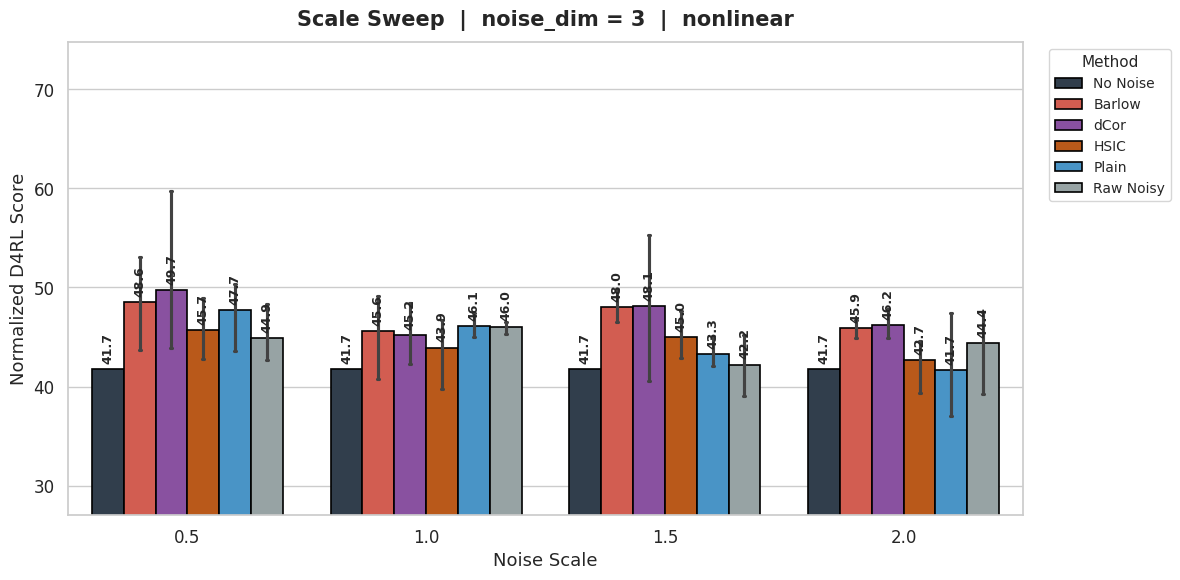

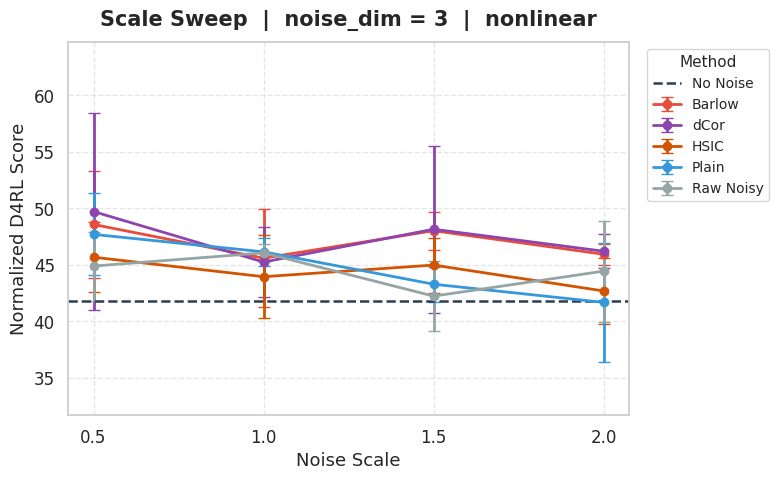

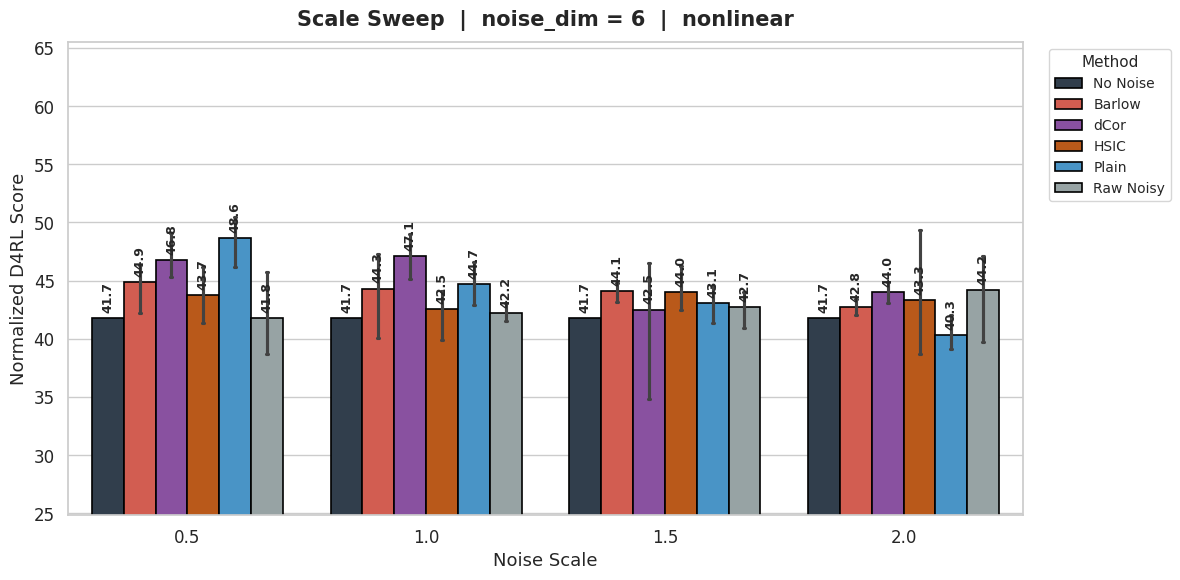

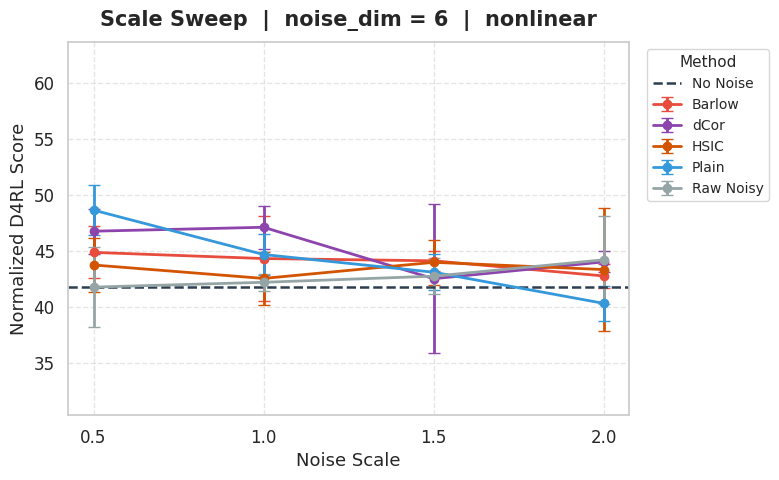

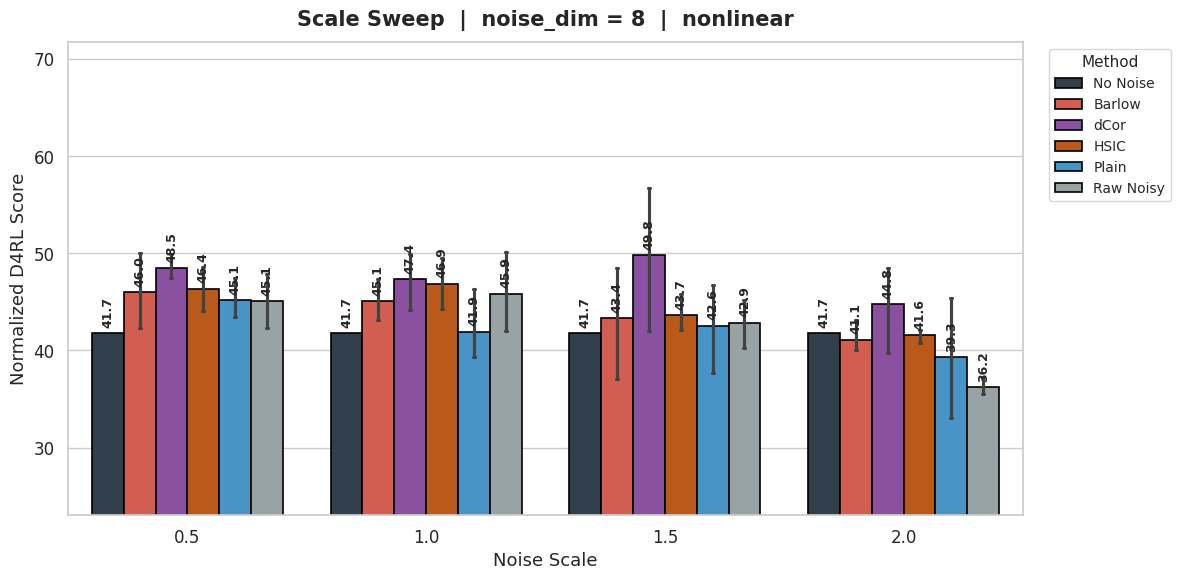

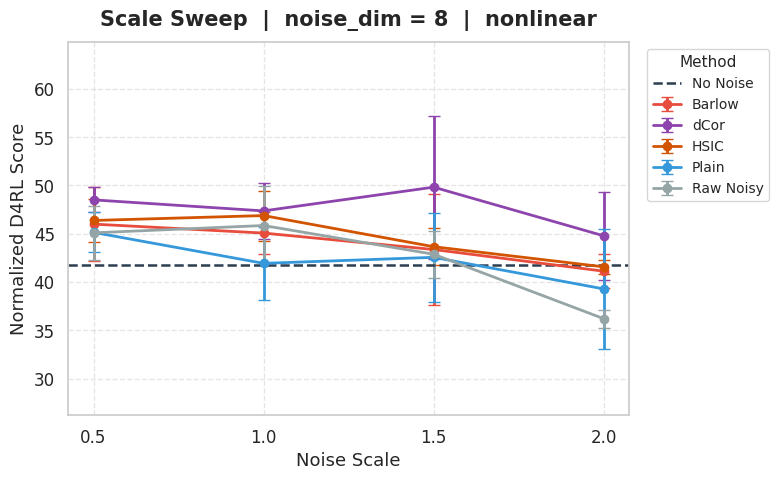

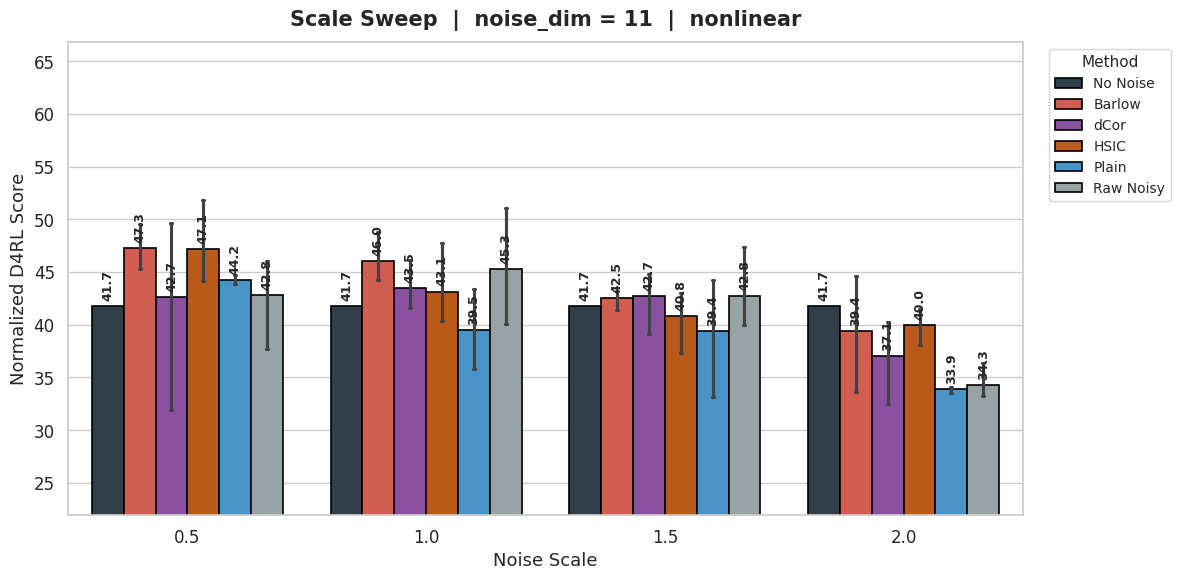

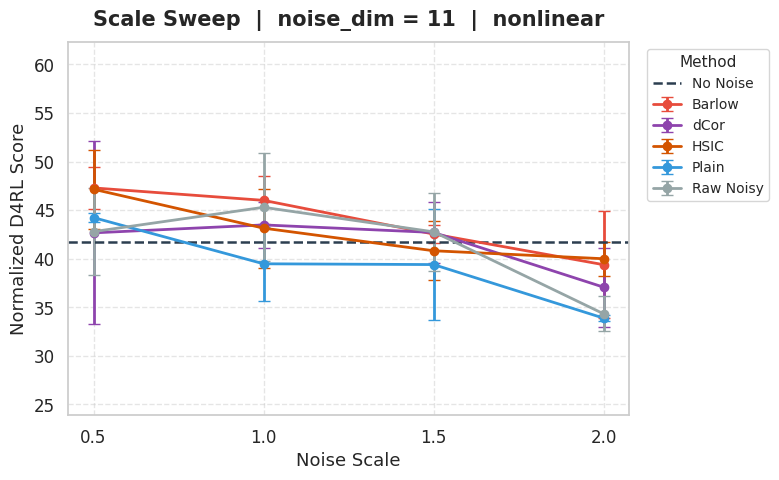

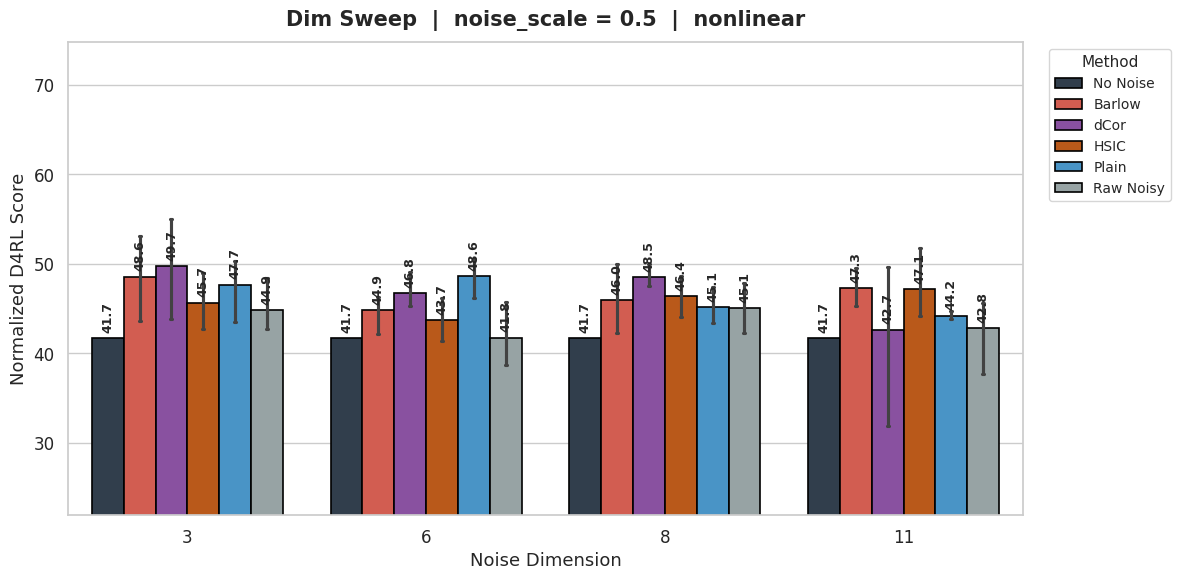

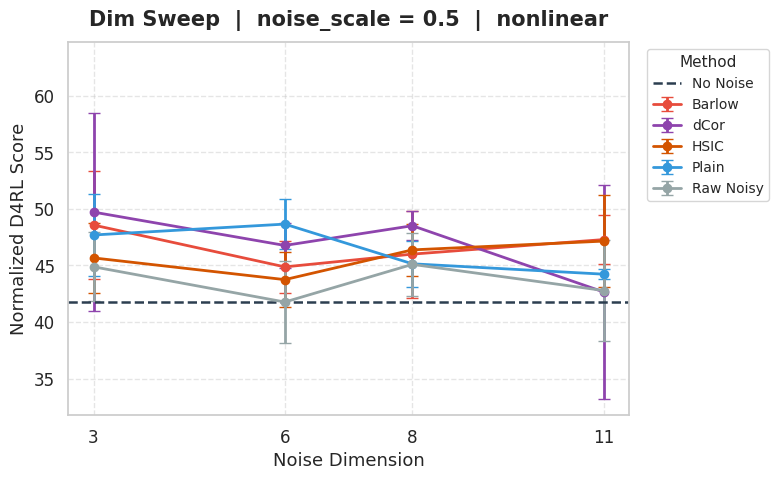

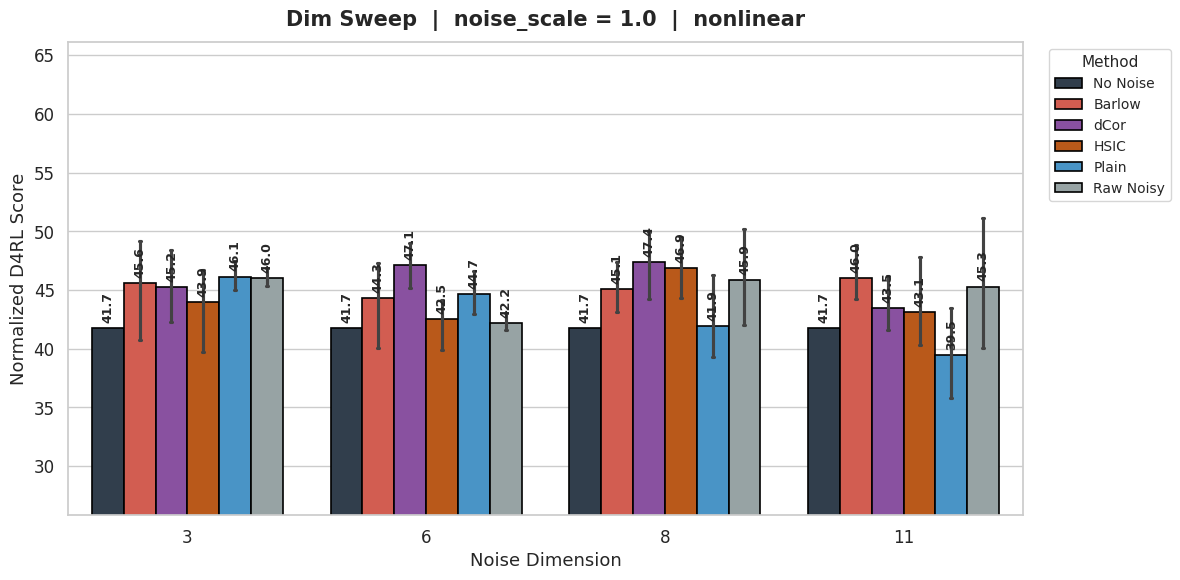

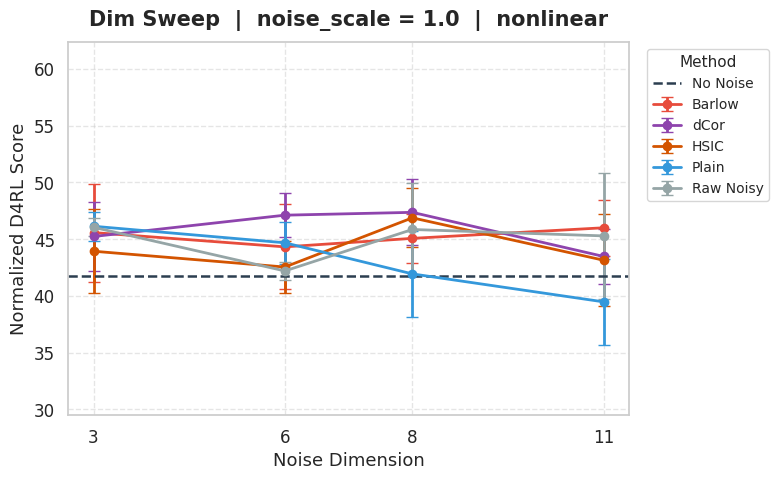

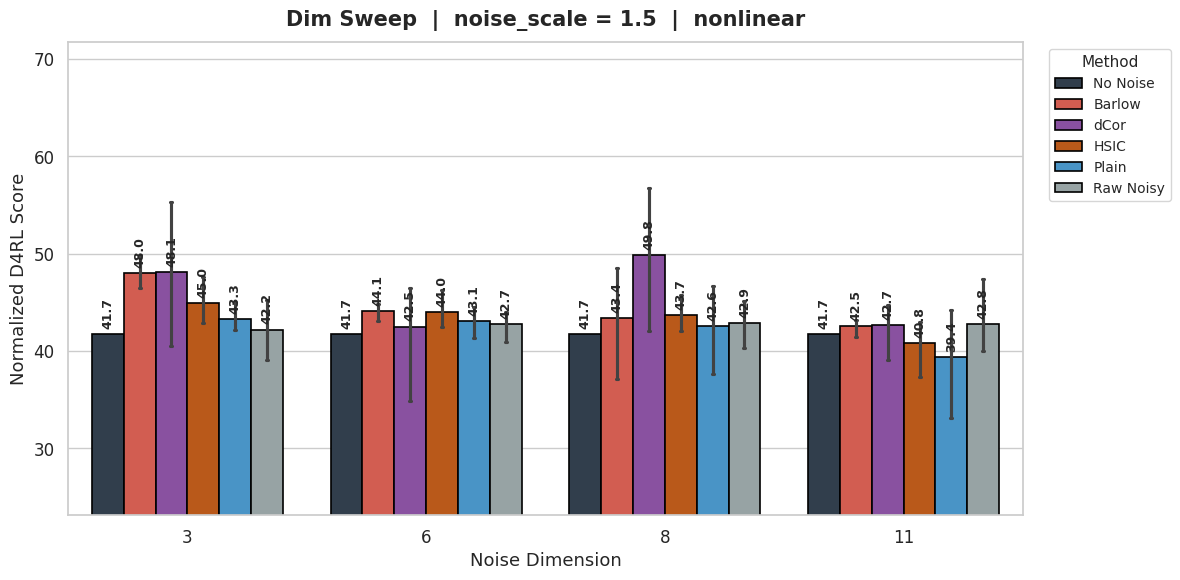

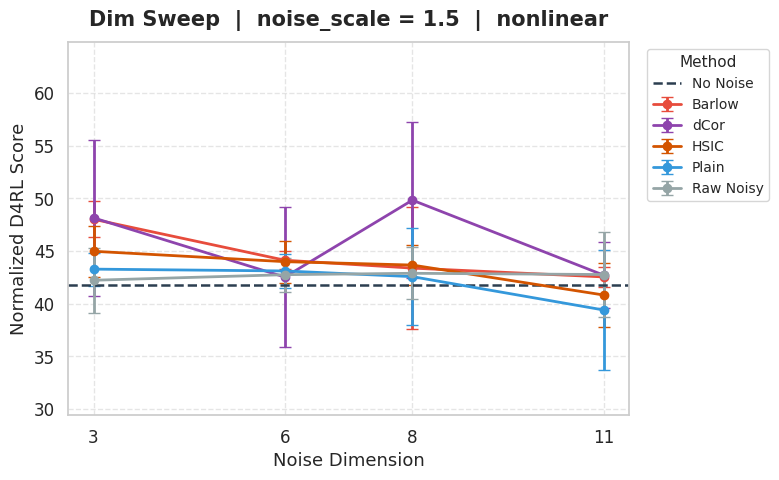

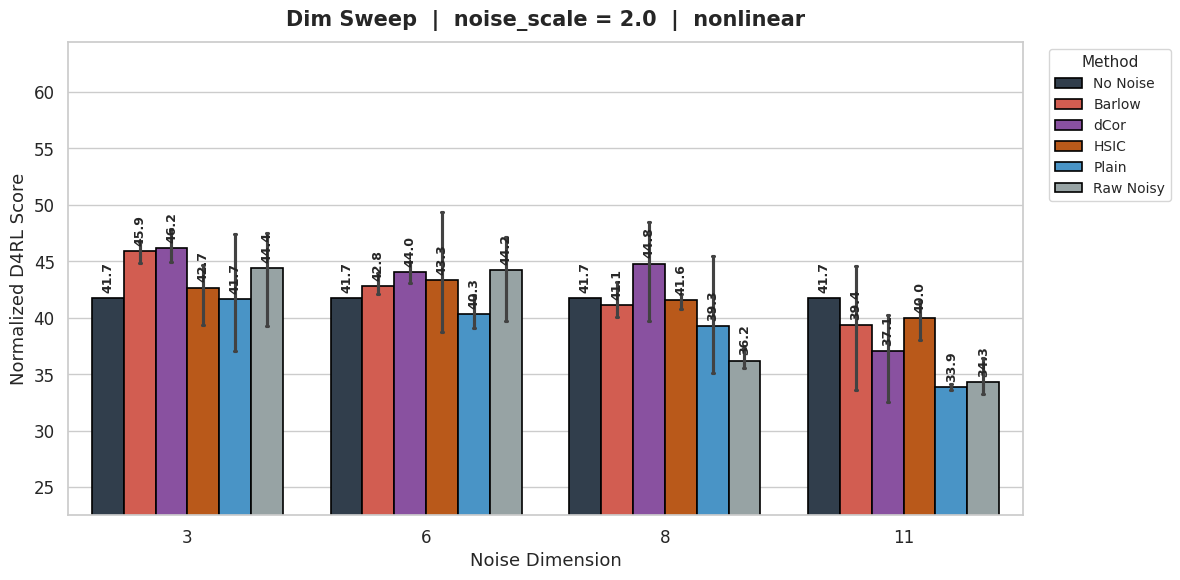

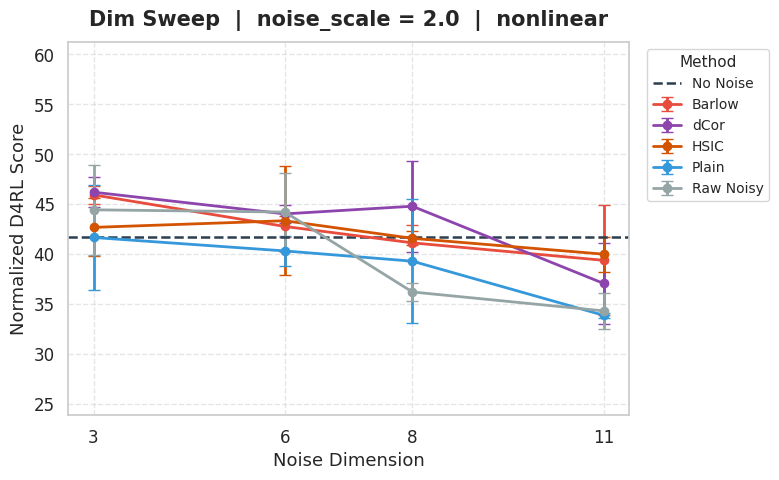

In [66]:
for env in TARGET_ENVS:
    d_n = df_noisy[df_noisy["Env"] == env]   if not df_noisy.empty  else pd.DataFrame()
    d_o = df_oracle[df_oracle["Env"] == env]  if not df_oracle.empty else pd.DataFrame()

    if d_n.empty:
        print(f"[WARN] No noise-sweep data for {env}, skipping figures.")
        continue

    oracle_mean_env = float(d_o["Score"].mean()) if not d_o.empty else None
    oracle_str = f"{oracle_mean_env:.2f}" if oracle_mean_env is not None else "N/A"
    fig_dir = FIGURES_MAIN_DIR / env / noise_type_str

    print(f"\n--- {env}  oracle={oracle_str} ---")
    generate_figures(
        df_noisy=d_n,
        target_dims=TARGET_DIMS,
        target_scales=TARGET_SCALES,
        noise_type_str=noise_type_str,
        fig_dir=fig_dir,
        method_labels=method_labels,
        global_order=global_order,
        palette=palette,
        oracle_mean=oracle_mean_env,
        save=SAVE_FIGURES,
        show=SHOW_FIGURES,
    )